# **15장. 트랜스포머의 원리와 구조**


---
## **[참고 동영상 1]**



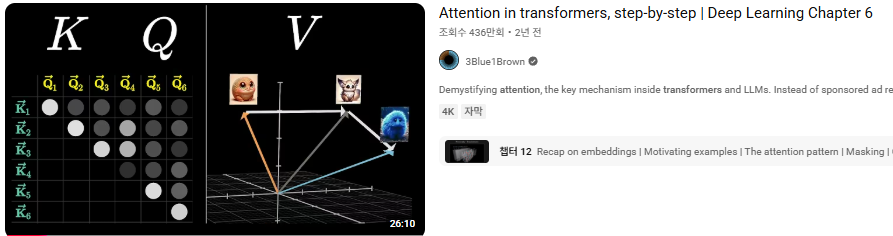

셀프 어텐션의 작동 원리와 멀티헤드 어텐션의 구조를 잘 설명하고 있는 이 동영상을 꼭 시청해봅시다.
* 원본 링크: https://youtu.be/eMlx5fFNoYc?si=M8FWisfjQmK1juKo (한글 자막이 지원됩니다)

* 한국어 더빙: https://youtu.be/_Z3rXeJahMs?si=oojbRE-dWdk6QVk-


---




**셀프어텐션**(Self-Attention)은 주어진 시퀀스 안의 각 토큰이 다른 모든 토큰과의 관계 속에서 자신의 **정체성**(identity)을 찾아가는 과정입니다.

각 토큰의 의미는 고립되어 독자적으로 결정되는 것이 아니라, 주변 토큰들과의 **관계**속에서 **문맥**에 맞는 새로운 의미를 가집니다.

셀프어텐션은 모든 토큰이 서로를 참조하며 찾아낸 관계를 종합하여 문장 전체의 맥락을 완성해 가는 방법입니다.

# **셀프 어텐션**의 단계별 실습 코드
**주어진 파라미터(가중치 행렬)에서 셀프 어텐션의 Q-K-V 알고리즘이 어떻게 작동하는지 단계적으로 알아봅시다.**

## 1. 임베딩으로 의미 벡터 만들기





In [ ]:
import numpy as np; import pandas as pd

np.set_printoptions(precision=3) # 소숫점 조정
np.random.seed(42)  # 랜덤 시드 고정

seq_length = 3      # 시퀀스 길이
dim = 4             # 임베딩 차원

# 랜덤 임베딩 벡터 생성
embed = np.random.randn(seq_length, dim)

# 결과 확인
print("입력 토큰별 임베딩:")
for i in range(3):
  print(f"{i+1}번 토큰--> {embed[i]}")

입력 토큰별 임베딩:
1번 토큰--> [ 0.497 -0.138  0.648  1.523]
2번 토큰--> [-0.234 -0.234  1.579  0.767]
3번 토큰--> [-0.469  0.543 -0.463 -0.466]


입력 시퀀스의 길이를 3, 임베딩 벡터의 차원을 4로 설정하였습니다.
* 임베딩 차원은 토큰들의 의미 정보를 얼마나 세밀하게 구분할지를 결정합니다.

임베딩 벡터는 모델의 학습과정에서 최적화되는 파라미터이지만 실습을 위해 무작위로 설정된 값을 사용해보겠습니다.
* np.random.randn()은 표준 정규분포를 따르는 난수를 추출하여 괄호안에 설정된 차원의 배열에 저장합니다.
* 그 결과를 embed라는 변수로 정의하고 출력하였습니다.
* 각 토큰별 4차원 임베딩 벡터가 만들어집니다.



## 2. 포지셔널 인코딩으로 위치 벡터 만들기


---
## **[참고 동영상 2]**



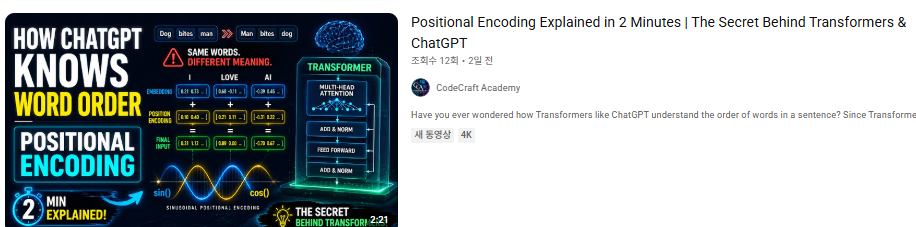

### https://www.youtube.com/watch?v=5Fu6ZNPPA-E

이 동영상은 포지셔널 인코딩의 필요성과 방법을 쉽게 설명합니다.

In [ ]:
# 포지셔널 인코딩 함수 정의
def positional_encoding(length, d):
    output=np.zeros((length, d))
    for pos in range(length):
        for i in range(d):
            if i % 2 == 0:  # 짝수 인덱스 → sin
                output[pos, i] = np.sin(pos / (10000 ** (i / d)))
            else:           # 홀수 인덱스 → cos
                output[pos, i] = np.cos(pos / (10000 ** ((i-1) / d)))
    return output

# 함수 호출
pe = positional_encoding(seq_length, dim)

print("토큰별 위치정보 벡터:")
for i in range(seq_length):
  print(f"{i+1}번 토큰--> {pe[i]}")


토큰별 위치정보 벡터:
1번 토큰--> [0. 1. 0. 1.]
2번 토큰--> [0.841 0.54  0.01  1.   ]
3번 토큰--> [ 0.909 -0.416  0.02   1.   ]


사용자 정의 함수 positional_encoding은 임베딩 벡터와 동일한 차원의 위치 벡터를 생성하는 함수입니다.
* 이 함수는 단어의 위치(pos)와 벡터의 차원 인덱스(i)를 조합해 고유한 값을 만듭니다.
* 짝수 번째 자릿수에는 사인 함수를, 홀수 번째 자릿수에는 코사인 함수를 사용합니다.
* 두 삼각함수는 일정한 파동을 가집니다. 마치 우리가 시간을 표시할 때 시침, 분침, 초침이 각기 다른 주기로 회전하며 현재 시각을 정확하게 나타내는 것처럼, 이 코드도 서로 다른 주기의 파동을 겹쳐서 토큰의 고유한 위치를 좌표로 변환해 줍니다.

이 함수에 시퀀스의 길이와 임베딩 차원을 입력하여 토큰별 위치 벡터를 계산한 다음 pe로 지정하고 출력하였습니다.   

* 자세한 위치 벡터 생성 규칙은 기억 못해도 좋습니다.
* 중요한 것은 이 규칙을 적용하면 토큰의 의미와 무관하게 시퀀스에서의 위치(순서)에 따라 고유한 값을 가진 벡터가 생성된다는 것입니다.


## 3. 임베딩 벡터와 위치 벡터 결합

In [ ]:
X=embed + pe   # 임베딩 벡터와 위치 벡터를 더함

print("토큰별 어텐션 입력 벡터:")

for i in range(seq_length):
  print(f"{i+1}번 토큰--> {X[i]}")

토큰별 어텐션 입력 벡터:
1번 토큰--> [0.497 0.862 0.648 2.523]
2번 토큰--> [0.607 0.306 1.589 1.767]
3번 토큰--> [ 0.44   0.126 -0.443  0.534]


임베딩 벡터와 위치 벡터를 더하여 각 토큰의 의미 정보와 위치 정보를 결합한 새로운 벡터를 만들고 출력하였습니다.

이것이 다음 셀프 어텐션 층으로 입력됩니다.  

## **[복습 동영상]**

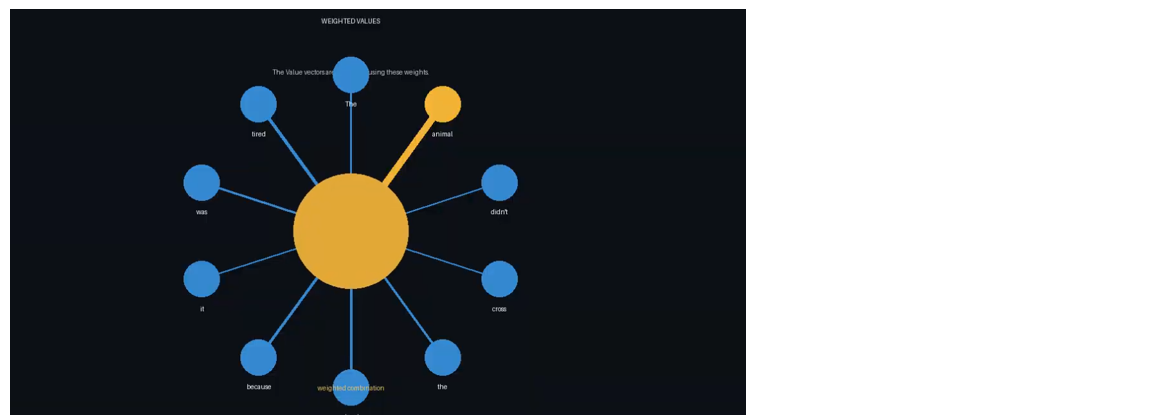

### https://drive.google.com/file/d/15lLqOj7GAbnZKlT1qOMSYhWapgO9qPo6/view?usp=sharing

직접 만든 이 동영상은 입력 시퀀스의 각 토큰이 **셀프 어텐션**을 통해 문맥이 반영된 **컨텍스트 벡터**로 변환되는 과정을 요약해서 보여줍니다.  

## 4-1. 셀프 어텐션: 각 토큰별 **Q, K, V** 벡터 만들기

In [ ]:
# Q, K, V 가중치 행렬(랜덤 생성)
np.random.seed(42)

W_Q = np.random.randn(dim, dim)
W_K = np.random.randn(dim, dim)
W_V = np.random.randn(dim, dim)

# 각 토큰별로 어텐션 입력벡터(X)를 가중치 행렬에 곱하여 Q, K, V 벡터 생성
Q=[]; K=[]; V=[]

for i in range(seq_length):
  Q.append(X[i] @ W_Q)  # @는 행렬곱
  K.append(X[i] @ W_K)
  V.append(X[i] @ W_V)

Q=np.array(Q); K=np.array(K); V=np.array(V)

for i in range(seq_length):
  print(f"{i+1}번 토큰의 Q-K-V:")
  print(f"   Q={Q[i]}");  print(f"   K={K[i]}");  print(f"   V={V[i]}")


1번 토큰의 Q-K-V:
   Q=[ 0.351 -4.746 -2.97  -0.302]
   K=[-1.108 -0.703 -2.656  2.987]
   V=[-3.079 -3.919 -1.973  2.035]
2번 토큰의 Q-K-V:
   Q=[-0.088 -2.675 -2.908 -0.574]
   K=[-2.093 -0.218 -3.423  2.577]
   V=[-1.384 -2.242 -0.905  0.709]
3번 토큰의 Q-K-V:
   Q=[ 0.526 -1.353 -0.231  0.673]
   K=[-0.34  -0.095 -0.202  0.021]
   V=[-1.097e+00 -1.173e+00 -8.589e-04  1.860e-01]


셀프 어텐션 층에서 첫번째 작업은 입력 시퀀스의 각 토큰별로 Q, K, V 벡터를 만드는 것입니다.   

핵심 파라미터인 Q-K-V 가중치 행렬을 무작위로 설정하였습니다.
그다음 토큰별 입력 벡터(X[i])와 각 가중치 행렬을 곱해서 토큰별 Q-K-V 벡터를 만들어 출력하였습니다.

* 실제 모델에서는 매 스텝마다 Q-K-V 벡터가 경사하강법으로 최적화됩니다.
* 토큰별 입력 벡터, X[i]가 4차원이고, 가중치 행렬은 4x4 차원이므로 결과는 Q-K-V도 모두 4차원 벡터가 됩니다.  

다음 행렬식으로 모든 토큰의 Q-K-V를 한 번에 계산할 수도 있습니다.

In [ ]:
print("Q(쿼리)"); print(X@W_Q); print()

print("K(키)"); print(X@W_K); print()

print("V(밸류)"); print(X@W_V)

Q(쿼리)
[[ 0.351 -4.746 -2.97  -0.302]
 [-0.088 -2.675 -2.908 -0.574]
 [ 0.526 -1.353 -0.231  0.673]]

K(키)
[[-1.108 -0.703 -2.656  2.987]
 [-2.093 -0.218 -3.423  2.577]
 [-0.34  -0.095 -0.202  0.021]]

V(밸류)
[[-3.079e+00 -3.919e+00 -1.973e+00  2.035e+00]
 [-1.384e+00 -2.242e+00 -9.050e-01  7.087e-01]
 [-1.097e+00 -1.173e+00 -8.589e-04  1.860e-01]]


## 4-2. 셀프 어텐션: 각 토큰별 어텐션 점수(attention score) 계산

In [ ]:
tok=2   # 관심 토큰 설정

scores=[]

for i in range(seq_length):
  scores.append(np.dot(Q[tok],K[i])/np.sqrt(dim)) # 내적 계산

scores=np.array(scores)

print(f"{tok+1}번 토큰에 대한 어텐션 점수:")
pd.DataFrame([scores], columns=["토큰1", "토큰2", "토큰3"], index=[f"토큰{tok+1}"])

3번 토큰에 대한 어텐션 점수:


,토큰1,토큰2,토큰3
토큰3,1.496187,0.859411,0.005636


벡터의 **내적**(dot product)을 사용하여 마지막 토큰인 tok=2의 어텐션 점수를 계산해봅시다.

반복문에서 관심 토큰의 쿼리인 Q[tok]와 각 토큰의 K를 내적하여 어텐션 점수(scores)로 저장하고 출력하였습니다.

* 단, 어텐션 점수가 너무 커지면 학습에 장애가 발생할 수 있기 때문에 내적을 sqrt(임베딩 차원)으로 나누어서 사용하는게 일반적입니다.
* 일종의 정규화라고 볼 수 있습니다.

## 4-3. 셀프 어텐션: 각 토큰별 어텐션 비율(attention weights) 계산

In [ ]:
def softmax(x):
    e_x = np.exp(x)
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

weight = softmax(scores)

print("3번 토큰의 어텐션 비율:")
pd.DataFrame([weight], columns=["토큰1", "토큰2", "토큰3"], index=[f"토큰{tok+1}"])

3번 토큰의 어텐션 비율:


,토큰1,토큰2,토큰3
토큰3,0.570046,0.301552,0.128402


소프트맥스 함수를 정의하여 어텐션 점수를 합이 1이 되는 비율로 변환하는 코드입니다.

* 분류 문제의 출력층에 사용한 소프트맥스 함수와 형태는 동일하지만 확률보다 문맥적 연관성의 비율이라는 의미를 가집니다.

## 4-4. 셀프 어텐션: 각 토큰별 **컨텍스트 벡터**(context vector) 만들기

In [ ]:
cv=weight[0]*V[0]+weight[1]*V[1]+weight[2]*V[2]  # 비율로 모든 토큰의 V를 가중 평균

print(f"{tok+1}번 토큰의 컨텍스트 벡터:")
print(cv)

3번 토큰의 컨텍스트 벡터:
[-2.313 -3.061 -1.398  1.398]


각 토큰의 V 벡터와 어텐션 비율을 곱하여 합산하면, 문맥을 반영한 컨텍스트 벡터가 만들어집니다.   

컨텍스트 벡터(cv)는 Q-K-V 메커니즘을 통해 의미+위치+문맥 정보가 모두 반영된 어텐션 층의 최종 출력 벡터를 말합니다.

* 관심 토큰을 tok=0 또는 tok=1로 바꾸어 실행하면 다른 토큰의 컨텍스트 벡터도 동일한 방법으로 구할 수 있습니다.



또는 다음과 같이 행렬식으로 **모든 토큰의 어텐션 비율과 컨텍스트 벡터를 한번에 계산**할 수 있습니다.

> $$\mathbf{Attention Weights} = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)$$

> $$\mathbf{Context Vectors} = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

> $\mathrm{K^T}\ $는 $\mathrm{K}$의 전치(transpose) 행렬입니다.
>> 이것은 $\mathrm{K}$ 행렬의 행과 열을 서로 맞바꿔서 만들어집니다.  
> 파이썬에서는 $\mathrm{K.T}$로 사용합니다.

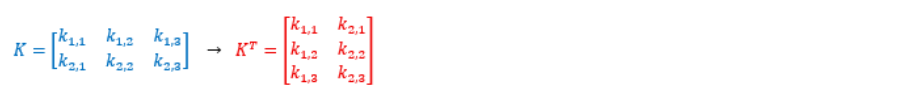

In [ ]:
# 행렬식을 사용하여 모든 토큰의 어텐션 비율 구하기
weights=softmax(Q@K.T / np.sqrt(dim))
print("모든 토큰의 어텐션 비율")
print(weights)

모든 토큰의 어텐션 비율
[[0.528 0.466 0.006]
 [0.345 0.646 0.01 ]
 [0.57  0.302 0.128]]


어텐션 비율을 히트맵으로 그려봅시다
- 각 행 토큰들이 열 토큰을 얼마나 참조하는지 시각화하는 도구입니다.   

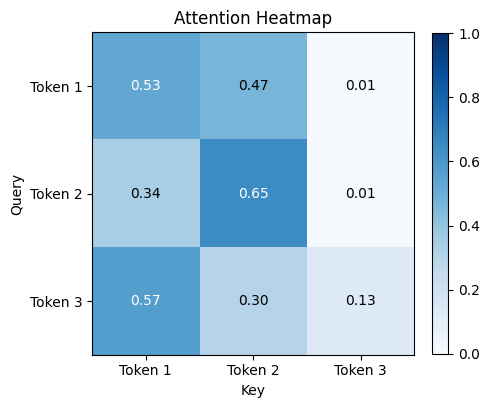

In [ ]:
import matplotlib.pyplot as plt

token_label = ["Token 1", "Token 2", "Token 3"]

fig, ax = plt.subplots(figsize=(5, 5))

# 히트맵
m = ax.imshow(weights, cmap="Blues", vmin=0, vmax=1)

# 축 레이블
ax.set_xticks(range(len(token_label)))
ax.set_yticks(range(len(token_label)))
ax.set_xticklabels(token_label)
ax.set_yticklabels(token_label)
ax.set_xlabel("Key")
ax.set_ylabel("Query")

# 각 셀에 숫자 표시
for i in range(weights.shape[0]):
    for j in range(weights.shape[1]):
        color = "white" if weights[i, j] > 0.5 else "black"
        ax.text(j, i,
                f"{weights[i, j]:.2f}",
                ha="center", va="center",
                color=color, fontsize=10)
# 컬러바 표시
plt.colorbar(m, ax=ax, fraction=0.045)
plt.title("Attention Heatmap")
plt.tight_layout()
plt.show()

행렬식으로 모든 토큰의 컨텍스트 벡터를 한번에 계산해 봅시다.

In [ ]:
# 일괄 계산
cv=softmax(Q@K.T/np.sqrt(dim))@V

print("모든 토큰의 컨텍스트 벡터 ")
print(cv); print()

# 토큰별 출력
for i in range(seq_length):
  print(f"{i+1}번 토큰--> {cv[i]}")

print()
print("이것이 어텐션 층의 출력 벡터입니다")

모든 토큰의 컨텍스트 벡터 
[[-2.276 -3.121 -1.463  1.406]
 [-1.965 -2.81  -1.264  1.161]
 [-2.313 -3.061 -1.398  1.398]]

1번 토큰--> [-2.276 -3.121 -1.463  1.406]
2번 토큰--> [-1.965 -2.81  -1.264  1.161]
3번 토큰--> [-2.313 -3.061 -1.398  1.398]

이것이 어텐션 층의 출력 벡터입니다


**순전파:** 이 컨텍스트 벡터가 FFN 층을 거쳐서 미세 조절된 후 Dense 출력층으로 연결되어 타깃 예측이 실행됩니다.

**역전파:** 손실을 줄이는 방향으로 모든 파라미터(임베딩벡터 + 가중치 행렬)가 업데이트됩니다.  


---



#### 트랜스포머 모델이 처음 제안된 기념비적인 논문입니다.

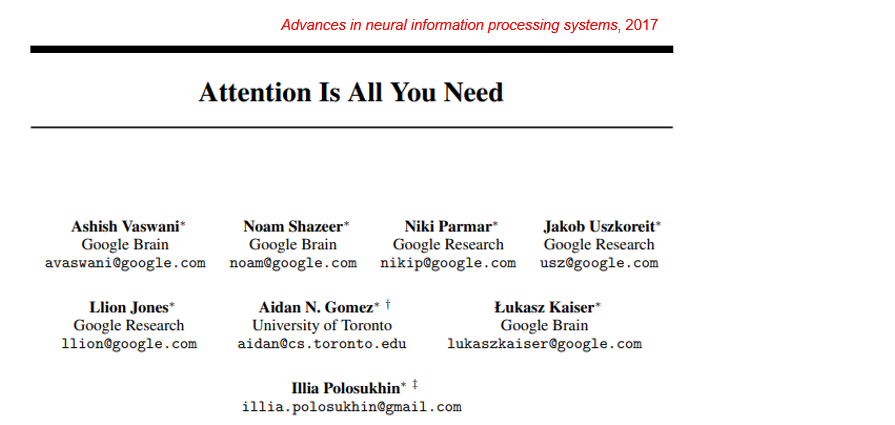